# TikTok Claims Classification

### Advanced Data Analytics and Machine Learning Case Study

Predicting whether a TikTok video contains a claim or an opinion using statistical analysis, feature engineering, text features, and machine learning.

**Tools:** Python, Pandas, NumPy, Scikit Learn, XGBoost, Matplotlib, Seaborn

**Project Context:** Google Advanced Data Analytics Professional Certificate

> **Note:** This case study uses a simulated dataset created for educational purposes.

## Executive Summary

This case study explores how machine learning can be used to classify TikTok videos as claims or opinions. The objective is to support the prioritization of user reported content for moderation by identifying videos that are more likely to contain claims.

The analysis combines exploratory data analysis, statistical analysis, feature engineering, text feature extraction, and supervised machine learning. Random Forest and XGBoost classification models are developed and evaluated using separate training, validation, and test datasets.

The analysis also examines which features contribute most strongly to the model's predictions, providing insight into the factors associated with claim classification.

The final model is evaluated using classification metrics including precision, recall, F1 score, and accuracy. The results are interpreted in the context of the dataset and its limitations, with recommendations for further validation before any real world deployment.

## 1. Business Problem

### Background

TikTok receives a large number of user reports identifying videos that may contain claims or other potentially problematic content. Because the volume of reported videos can exceed the capacity available for manual review, an efficient way to prioritize content for moderation can help the review process focus on the most relevant reports.

### Problem Statement

The goal of this project is to develop a machine learning model that can classify TikTok videos as either **claims** or **opinions**.

A successful classification approach could help prioritize reported videos for further review by identifying content that is more likely to contain a claim.

### Analytical Objective

The objective is to determine whether the available video, engagement, and text related features contain enough predictive information to distinguish between claims and opinions.

The analysis will focus on:

1. Understanding the structure and quality of the available data.
2. Identifying patterns and relationships associated with the target variable.
3. Applying statistical analysis to investigate relevant relationships.
4. Engineering useful features from the available data.
5. Extracting features from video transcription text.
6. Building and comparing machine learning classification models.
7. Evaluating model performance using appropriate classification metrics.
8. Interpreting the model results and identifying important predictive features.

### Success Criteria

The models will be evaluated using precision, recall, F1 score, and accuracy. Model selection will consider the practical objective of identifying claims while maintaining an appropriate balance between detecting relevant content and limiting incorrect classifications.

## 2. Import Libraries


In [6]:

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils import resample

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Text feature extraction
from sklearn.feature_extraction.text import CountVectorizer

# Display settings
pd.set_option("display.max_columns", None)

In [7]:

# Load the dataset
df = pd.read_csv("C:\\Users\\king\\OneDrive\\سطح المكتب\\ADA\\TickTock\\New_ticktock\\Files\\tiktok_dataset.csv")

# Display the first five rows
df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


## 3. Initial Data Inspection

Before performing any analysis, we first examine the dataset structure, data types, and completeness.

In [8]:

# Preview the dataset
df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


### Dataset Structure

In [9]:
# Dataset dimensions
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

# Data types and non-null counts
df.info()

Rows: 19,382
Columns: 12
<class 'pandas.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  str    
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  str    
 5   verified_status           19382 non-null  str    
 6   author_ban_status         19382 non-null  str    
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), str(4)
memory usage: 1.8 MB


### Descriptive Statistics

Summary statistics are used to understand the central tendency, spread, and range of the numerical variables.

In [10]:
df.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


### Missing Values

We check the dataset for missing values before deciding how they should be handled.

In [11]:

# Missing values
missing = df.isna().sum()

missing[missing > 0].sort_values(ascending=False)

claim_status                298
video_transcription_text    298
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

### Missing Value Findings

The dataset contains 298 incomplete records with missing values across the target variable, transcription text, and video engagement metrics.

Because the missing records affect the target variable and several important features, these incomplete records are removed before further analysis.

In [12]:

# Remove incomplete records
df = df.dropna().copy()

print(f"Rows after removing incomplete records: {df.shape[0]:,}")
print(f"Rows removed: {19_382 - df.shape[0]:,}")

Rows after removing incomplete records: 19,084
Rows removed: 298


### Duplicate Records

We check for fully duplicated records to ensure that repeated observations do not affect the analysis.

In [13]:

# Check for duplicate records
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


No duplicated records were found in the dataset.

### Initial Data Quality Findings

The initial inspection shows that the dataset contains a mix of numerical, categorical, and text variables. The numerical engagement features also show highly skewed distributions, with some values substantially higher than their median levels.

There are 298 incomplete records affecting the target and several associated features, while no fully duplicated records were identified.

These findings will guide the data cleaning and exploratory analysis that follow.

## 4. DATA QUALITY ASSESSMENT AND EXPLORATORY ANALYSIS
The dataset is further examined for duplicate records, class distribution, and potential relationships between video characteristics, engagement, and content classification.



In [14]:

# Check for duplicate records
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")


Duplicate rows: 0


### Claim Status Distribution

We examine the distribution of the target variable to determine whether the dataset is reasonably balanced between claims and opinions.

In [15]:

# Distribution of the target variable
claim_distribution = df["claim_status"].value_counts()

print(claim_distribution)
print()
print((df["claim_status"].value_counts(normalize=True) * 100).round(2))


claim_status
claim      9608
opinion    9476
Name: count, dtype: int64

claim_status
claim      50.35
opinion    49.65
Name: proportion, dtype: float64


The two classes are relatively balanced, with claims and opinions representing approximately half of the labeled observations each.

This is useful for the later classification stage because the model will not be trained on a severely imbalanced target.

### Engagement by Claim Status

We compare video views between claims and opinions to investigate whether engagement is associated with the target variable.

In [16]:

# Compare view counts by claim status
view_summary = df.groupby("claim_status")["video_view_count"].agg(
    ["count", "mean", "median"]
)

view_summary

,count,mean,median
claim_status,,,
claim,9608,501029.452748,501555.0
opinion,9476,4956.432250,4953.0


The mean and median view counts should be compared together because the engagement variables are highly skewed.

In the original dataset, claim videos have substantially higher view counts than opinion videos. The difference is large enough to justify further investigation.

However, this comparison alone does not establish that claim status causes higher engagement. It only shows an association within this dataset.

### Engagement by Author Ban Status

We examine whether author status is associated with video engagement.


In [17]:

# Compare engagement metrics by author ban status
ban_engagement = df.groupby("author_ban_status").agg(
    video_count=("video_id", "count"),
    views_mean=("video_view_count", "mean"),
    views_median=("video_view_count", "median"),
    likes_mean=("video_like_count", "mean"),
    likes_median=("video_like_count", "median"),
    shares_mean=("video_share_count", "mean"),
    shares_median=("video_share_count", "median")
)

ban_engagement

,video_count,views_mean,views_median,likes_mean,likes_median,shares_mean,shares_median
author_ban_status,,,,,,,
active,15383,215927.039524,8616.0,71036.533836,2222.0,14111.466164,437.0
banned,1635,445845.439144,448201.0,153017.236697,105573.0,29998.942508,14468.0
under review,2066,392204.836399,365245.5,128718.050339,71204.5,25774.696999,9444.0



The mean values are expected to be considerably higher than the medians in several groups, which is consistent with the strong right skew already observed in the engagement variables.

Comparing the median values is particularly useful here because they are less sensitive to extremely high engagement observations.

If banned or under review authors show higher engagement than active authors, this indicates an association between author status and engagement, but it does not establish the reason for that relationship.

### Engagement Rates

Raw engagement counts are strongly influenced by the number of views. To make the comparison more meaningful, we calculate engagement relative to video views.

In [18]:

# Calculate engagement rates relative to views
df["likes_per_view"] = df["video_like_count"] / df["video_view_count"]
df["comments_per_view"] = df["video_comment_count"] / df["video_view_count"]
df["shares_per_view"] = df["video_share_count"] / df["video_view_count"]

# Check for any undefined values
df[["likes_per_view", "comments_per_view", "shares_per_view"]].isna().sum()


likes_per_view       0
comments_per_view    0
shares_per_view      0
dtype: int64

These ratios provide a normalized view of engagement.

Raw counts tell us how much engagement a video received, while engagement rates tell us how much interaction occurred relative to the number of views.

This distinction is important because a video with many views will naturally tend to have larger raw engagement counts.

In [19]:

# Compare engagement rates by claim status and author ban status
engagement_rates = df.groupby(
    ["claim_status", "author_ban_status"]
).agg(
    likes_per_view_mean=("likes_per_view", "mean"),
    likes_per_view_median=("likes_per_view", "median"),
    comments_per_view_mean=("comments_per_view", "mean"),
    comments_per_view_median=("comments_per_view", "median"),
    shares_per_view_mean=("shares_per_view", "mean"),
    shares_per_view_median=("shares_per_view", "median")
)
engagement_rates


likes_per_view_mean  likes_per_view_median  \
claim_status author_ban_status                                               
claim        active                        0.329542               0.326538   
             banned                        0.345071               0.358909   
             under review                  0.327997               0.320867   
opinion      active                        0.219744               0.218330   
             banned                        0.206868               0.198483   
             under review                  0.226394               0.228051   

                                comments_per_view_mean  \
claim_status author_ban_status                           
claim        active                           0.001393   
             banned                           0.001377   
             under review                     0.001367   
opinion      active                           0.000517   
             banned                           0.000434   
             under review                     0.000536   

                                comments_per_view_median  \
claim_status author_ban_status                             
claim        active                             0.000776   
             banned                             0.000746   
             under review                       0.000789   
opinion      active                             0.000252   
             banned                             0.000193   
             under review                       0.000293   

                                shares_per_view_mean  shares_per_view_median  
claim_status author_ban_status                                                
claim        active                         0.065456                0.049279  
             banned                         0.067893                0.051606  
             under review                   0.065733                0.049967  
opinion      active                         0.043729                0.032405  
             banned                         0.040531                0.030728  
             under review                   0.044472                0.035027

The normalized metrics help separate overall popularity from engagement intensity.

Differences between claim and opinion videos can therefore be investigated without relying only on the absolute number of views, likes, comments, or shares.



### Exploratory Findings

The initial analysis indicates that claim status is associated with substantial differences in video engagement. Author status also appears to be associated with engagement levels.

These relationships provide useful signals for the statistical analysis and predictive modeling stages. They should be treated as associations rather than causal relationships.

## 5. Statistical Analysis and Hypothesis Testing

The exploratory analysis suggests a difference in video views between verified and unverified accounts.

We test this difference statistically using a two sample Welch's t test.

### Research Question

Do videos posted by verified accounts and videos posted by unverified accounts have different mean view counts?



#### Hypotheses

**Null hypothesis (H₀):** There is no difference in the mean video view count between verified and unverified accounts.

**Alternative hypothesis (H₁):** There is a difference in the mean video view count between verified and unverified accounts.

The significance level is set to 5%.

In [20]:

# Separate view counts by verification status
not_verified = df.loc[
    df["verified_status"] == "not verified",
    "video_view_count"
]

verified = df.loc[
    df["verified_status"] == "verified",
    "video_view_count"
]

# Compare the two means
print("Mean views for unverified accounts:", not_verified.mean())
print("Mean views for verified accounts:", verified.mean())


Mean views for unverified accounts: 265663.78533885034
Mean views for verified accounts: 91439.16416666667


### Welch's Two Sample t Test

Welch's t test is used because the two groups may have different variances and sample sizes.

If the p value is below 0.05, we reject the null hypothesis and conclude that the sample provides statistically significant evidence of a difference in mean video views between verified and unverified accounts.

If the p value is above 0.05, we do not reject the null hypothesis

In [21]:

# Conduct Welch's two sample t test
not_verified_clean = not_verified.dropna() #drop na values from the not_verified series so that the t-test can be performed without errors
verified_clean = verified.dropna() #drop na values from the verified series so that the t-test can be performed without errors

t_statistic, p_value = stats.ttest_ind(
    not_verified_clean,
    verified_clean,
    equal_var=False
)

print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.6g}")

t-statistic: 25.4994
p-value: 2.60888e-120


### Statistical Conclusion

The Welch's two sample t test produced a p value of approximately 2.61 × 10⁻¹²⁰, which is far below the 0.05 significance level.

The mean video view count was substantially higher for unverified accounts than for verified accounts, with average view counts of approximately 265,664 and 91,439 respectively.

Therefore, we reject the null hypothesis and conclude that the dataset provides strong statistical evidence of a difference in mean video views between the two groups.

This result describes an association within the dataset and does not imply that verification status causes differences in video views.

## 6. Logistic Regression

The next stage models whether an account is verified or unverified.

Logistic regression is appropriate because the outcome variable is binary.

### Feature Selection

The identifier columns are excluded because they do not provide meaningful information for predicting account verification status.

Video like count is also excluded because the exploratory correlation analysis showed a strong relationship between likes and views.


In [22]:

# Select the outcome variable
y = df["verified_status"]

# Select candidate features
X = df[
    [
        "video_duration_sec",
        "claim_status",
        "author_ban_status",
        "video_view_count",
        "video_share_count",
        "video_download_count",
        "video_comment_count"
    ]
].copy()

X.head()

,video_duration_sec,claim_status,author_ban_status,video_view_count,video_share_count,video_download_count,video_comment_count
0,59,claim,under review,343296.0,241.0,1.0,0.0
1,32,claim,active,140877.0,19034.0,1161.0,684.0
2,31,claim,active,902185.0,2858.0,833.0,329.0
3,25,claim,active,437506.0,34812.0,1234.0,584.0
4,19,claim,active,56167.0,4110.0,547.0,152.0


### Check Multicollinearity

Correlation analysis is used to identify highly correlated numerical predictors before fitting the logistic regression model.

In [23]:

# Correlation matrix for numerical variables
correlation_matrix = df[
    [
        "video_duration_sec",
        "video_view_count",
        "video_like_count",
        "video_share_count",
        "video_download_count",
        "video_comment_count"
    ]
].corr()

correlation_matrix

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
video_duration_sec,1.000000,0.008481,0.011567,0.011560,0.013078,0.000615
video_view_count,0.008481,1.000000,0.804322,0.665635,0.664222,0.554172
video_like_count,0.011567,0.804322,1.000000,0.825789,0.823554,0.687185
video_share_count,0.011560,0.665635,0.825789,1.000000,0.679910,0.574632
video_download_count,0.013078,0.664222,0.823554,0.679910,1.000000,0.832464
video_comment_count,0.000615,0.554172,0.687185,0.574632,0.832464,1.000000


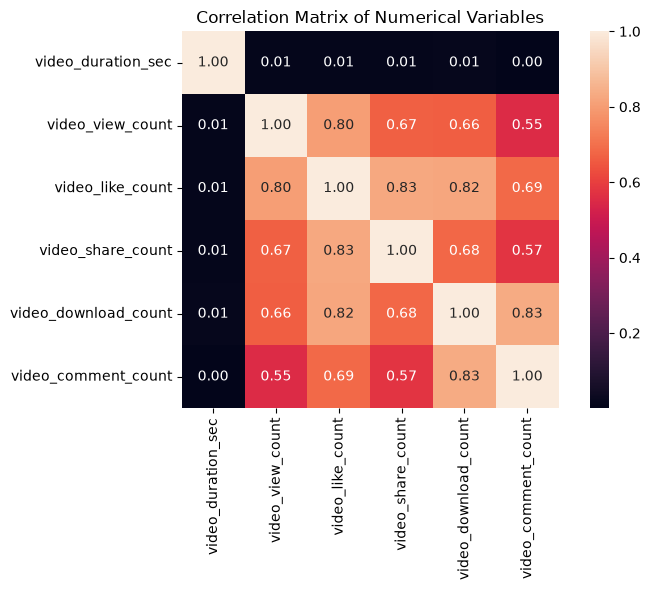

In [24]:

# Visualize the correlation matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

### Correlation Findings

The correlation matrix shows a very strong positive correlation between `video_view_count` and `video_like_count` (r = 0.99).

This indicates that these two variables contain highly overlapping information. Including both in a logistic regression model could make the individual effect of each predictor more difficult to interpret due to multicollinearity.

For this reason, `video_like_count` is excluded from the logistic regression model, while `video_view_count` is retained as the primary engagement feature.

### Train Test Split

The data is split before encoding and any resampling to avoid information leakage between the training and testing sets.

In [25]:

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=0,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (14313, 7)
X_test : (4771, 7)
y_train: (14313,)
y_test : (4771,)


### Class Distribution

The verification status is strongly imbalanced, so the training data will be balanced before model fitting.

In [26]:

# Check class distribution in the training data
y_train.value_counts(normalize=True)


verified_status
not verified    0.93712
verified        0.06288
Name: proportion, dtype: float64


### Balance the Training Data

Only the training data is resampled. The test data remains untouched so that final evaluation represents the original class distribution.

In [27]:

# Separate majority and minority classes
train_data = X_train.copy()
train_data["verified_status"] = y_train.values

majority = train_data[
    train_data["verified_status"] == "not verified"
]

minority = train_data[
    train_data["verified_status"] == "verified"
]

# Upsample the minority class
minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=0
)

# Combine the balanced training data
train_balanced = pd.concat(
    [majority, minority_upsampled],
    axis=0
).sample(
    frac=1,
    random_state=0
).reset_index(drop=True)

print(train_balanced["verified_status"].value_counts())


verified_status
verified        13413
not verified    13413
Name: count, dtype: int64


The training data is now balanced by increasing the representation of the minority class.

The important point is that only the training data was resampled. The test set was not modified, which prevents the evaluation from being artificially influenced by duplicated observations.


### Encode Categorical Features

Categorical predictors are converted into numerical features using one hot encoding.


In [28]:

# Separate features and target
X_train_balanced = train_balanced.drop(columns="verified_status")
y_train_balanced = train_balanced["verified_status"]

X_test_encoded_source = X_test.copy()

# Identify categorical columns
categorical_features = [
    "claim_status",
    "author_ban_status"
]

# Fit encoder on training data only
encoder = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

X_train_categorical = encoder.fit_transform(
    X_train_balanced[categorical_features]
)

X_test_categorical = encoder.transform(
    X_test_encoded_source[categorical_features]
)

# Convert encoded features to DataFrames
encoded_columns = encoder.get_feature_names_out(
    categorical_features
)

X_train_categorical_df = pd.DataFrame(
    X_train_categorical,
    columns=encoded_columns
)

X_test_categorical_df = pd.DataFrame(
    X_test_categorical,
    columns=encoded_columns
)

# Numerical features
numerical_features = [
    "video_duration_sec",
    "video_view_count",
    "video_share_count",
    "video_download_count",
    "video_comment_count"
]

X_train_numerical = X_train_balanced[
    numerical_features
].reset_index(drop=True)

X_test_numerical = X_test[
    numerical_features
].reset_index(drop=True)

# Final feature matrices
X_train_final = pd.concat(
    [X_train_numerical, X_train_categorical_df],
    axis=1
)

X_test_final = pd.concat(
    [X_test_numerical, X_test_categorical_df],
    axis=1
)

X_train_final.head()

,video_duration_sec,video_view_count,video_share_count,video_download_count,video_comment_count,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,30,763160.0,110521.0,5139.0,2057.0,0.0,0.0,0.0
1,44,9353.0,31.0,0.0,0.0,1.0,0.0,0.0
2,38,538799.0,4728.0,1617.0,981.0,0.0,0.0,0.0
3,23,8129.0,591.0,31.0,8.0,1.0,1.0,0.0
4,24,764.0,51.0,1.0,0.0,1.0,0.0,0.0


### Encode the Target

The binary target is converted to 0 and 1 for logistic regression.


In [29]:

# Encode target
target_mapping = {
    "not verified": 0,
    "verified": 1
}

y_train_final = y_train_balanced.map(target_mapping)
y_test_final = y_test.map(target_mapping)

print(y_train_final.value_counts())
print()
print(y_test_final.value_counts())

verified_status
1    13413
0    13413
Name: count, dtype: int64

verified_status
0    4471
1     300
Name: count, dtype: int64



### Build the Logistic Regression Model

In [30]:

# Train logistic regression
log_clf = LogisticRegression(
    random_state=0,
    max_iter=1000
)

log_clf.fit(
    X_train_final,
    y_train_final
)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",0
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

### Evaluate Logistic Regression

The model is evaluated on the untouched test set using precision, recall, F1 score, accuracy, and a confusion matrix.

In [31]:

# Generate predictions
log_pred = log_clf.predict(X_test_final)

# Classification report
print(
    classification_report(
        y_test_final,
        log_pred,
        target_names=["not verified", "verified"],
        digits=3
    )
)

              precision    recall  f1-score   support

not verified      0.977     0.533     0.690      4471
    verified      0.105     0.813     0.186       300

    accuracy                          0.551      4771
   macro avg      0.541     0.673     0.438      4771
weighted avg      0.922     0.551     0.658      4771



### Model Performance Interpretation

The logistic regression model shows a clear tradeoff between identifying verified accounts and avoiding false positive predictions.

For the `verified` class, the model achieves a recall of **0.813**, meaning it identifies most of the verified accounts in the test set.

However, precision for the `verified` class is only **0.105**, meaning that a large proportion of accounts predicted as verified are actually unverified.

The model achieves an overall accuracy of **0.551**, while the F1 score for the verified class is only **0.186**. The low F1 score reflects the imbalance between relatively high recall and very low precision.

These results indicate that the logistic regression model is able to detect many verified accounts, but it generates a substantial number of false positive predictions. Therefore, accuracy alone would give an incomplete picture of model performance, and precision, recall, and F1 score provide more useful insight into the model's behavior.

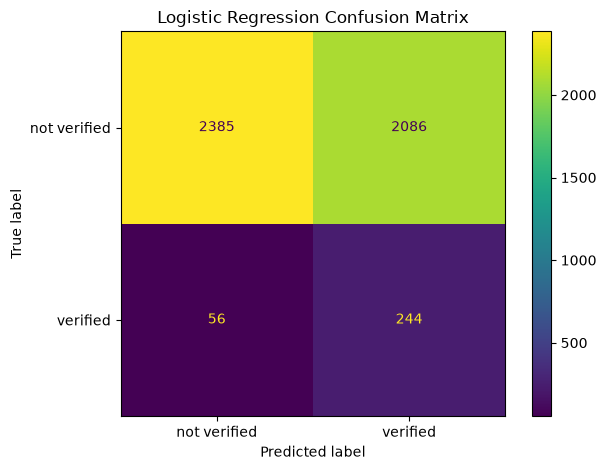

In [32]:

# Confusion matrix
log_cm = confusion_matrix(
    y_test_final,
    log_pred,
    labels=[0, 1]
)

log_disp = ConfusionMatrixDisplay(
    confusion_matrix=log_cm,
    display_labels=["not verified", "verified"]
)

log_disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrix provides a clearer view of the model's classification errors.

The model correctly identifies 244 of the 300 verified accounts, resulting in a relatively high recall of 81.3%.

However, it incorrectly classifies 2,086 unverified accounts as verified. This large number of false positives explains the very low precision of 10.5% for the verified class.

Overall, the model is effective at capturing a large proportion of verified accounts, but it produces too many false positive predictions. This limits its practical usefulness when accurate identification of verified accounts is required.


### Model Coefficients

The logistic regression coefficients indicate the direction of the relationship between each feature and the predicted log odds of an account being verified.

In [33]:

# Display model coefficients
coefficient_df = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Coefficient": log_clf.coef_[0]
})

coefficient_df = coefficient_df.sort_values(
    "Coefficient",
    ascending=False
)

coefficient_df


,Feature,Coefficient
5,claim_status_opinion,1.615381e+00
4,video_comment_count,2.063953e-04
2,video_share_count,7.644577e-06
1,video_view_count,-3.426304e-07
3,video_download_count,-1.175004e-04
0,video_duration_sec,-4.212052e-03
6,author_ban_status_banned,-1.666921e-01
7,author_ban_status_under review,-2.236558e-01


### Coefficient Interpretation

The coefficients show the direction and relative strength of the association between each predictor and the probability of an account being verified.

`claim_status_opinion` has the largest positive coefficient (1.615), indicating that, relative to the reference claim category, opinion classified videos are associated with higher log odds of verification in this model.

The categorical author status variables have negative coefficients. Both `banned` and `under review` are associated with lower log odds of verification compared with the reference author status category.

The numerical engagement variables have relatively small coefficients because they are measured on very different scales. Therefore, their coefficient magnitudes should not be compared directly without considering the scale of each feature.

These coefficients represent associations within the logistic regression model and should not be interpreted as causal effects.

## 7. Machine Learning Classification

The final modeling stage focuses on the main business objective: classifying videos as claims or opinions.

Two tree based ensemble models will be developed and compared:

1. Random Forest
2. XGBoost

The models will be evaluated using validation data before the final model is assessed on the held out test set.

### Modeling Objective

The target variable is `claim_status`.

The goal is to identify videos that are more likely to contain claims and could therefore be prioritized for further review.


### Feature Engineering

The transcription text is converted into numerical features so that machine learning models can use information contained in the video text.

In [34]:

# Create text length feature
df["text_length"] = df["video_transcription_text"].str.len()

# Compare average transcription length by claim status
text_length_summary = df.groupby(
    "claim_status"
)["text_length"].agg(
    ["count", "mean", "median"]
)

text_length_summary

,count,mean,median
claim_status,,,
claim,9608,95.376978,93.0
opinion,9476,82.722562,80.0


### Transcription Length Findings

Claim videos have longer transcriptions than opinion videos.

The mean transcription length is approximately **95.4 characters** for claims compared with **82.7 characters** for opinions. The median shows a similar pattern, with **93 characters** for claims versus **80 characters** for opinions.

This consistent difference suggests that transcription length may contain useful predictive information for distinguishing claims from opinions.

However, the difference alone is not sufficient to classify a video reliably. The full transcription text will therefore be converted into numerical features using text vectorization and combined with the structured video features in the machine learning models.

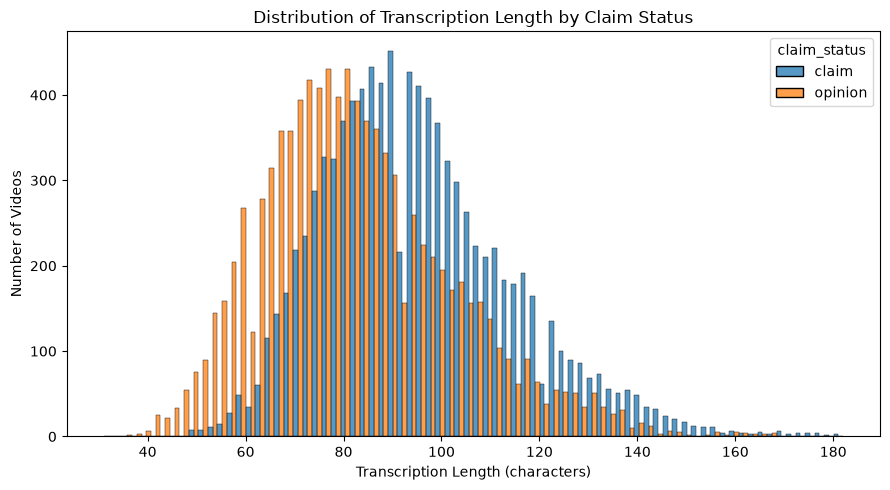

In [35]:

# Visualize transcription length by claim status
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="text_length",
    hue="claim_status",
    multiple="dodge",
    kde=False
)

plt.xlabel("Transcription Length (characters)")
plt.ylabel("Number of Videos")
plt.title("Distribution of Transcription Length by Claim Status")
plt.tight_layout()
plt.show()

### Distribution Findings

The distribution shows a clear shift toward longer transcriptions for claim videos compared with opinion videos.

Claim videos are more concentrated at higher transcription lengths, while opinion videos are more concentrated at shorter lengths. There is still substantial overlap between the two distributions, which indicates that transcription length alone cannot reliably distinguish claims from opinions.

This visual pattern is consistent with the earlier summary statistics, where claim videos had both a higher mean and median transcription length.

The overlap between the two classes also supports using the full transcription text rather than relying only on text length as a predictive feature.

### Prepare the Modeling Dataset

Identifier columns are removed because they do not represent meaningful predictive information.

The target is encoded as 0 for opinion and 1 for claim.



In [36]:

# Create a modeling copy
model_data = df.copy()

# Remove identifier columns
model_data = model_data.drop(
    columns=["#", "video_id"]
)

# Encode target
model_data["claim_status"] = model_data[
    "claim_status"
].map({
    "opinion": 0,
    "claim": 1
})

# Encode categorical predictors
model_data = pd.get_dummies(
    model_data,
    columns=[
        "verified_status",
        "author_ban_status"
    ],
    drop_first=True
)

model_data.head()

,claim_status,video_duration_sec,video_transcription_text,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,likes_per_view,comments_per_view,shares_per_view,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,1,59,someone shared with me that drone deliveries a...,343296.0,19425.0,241.0,1.0,0.0,0.056584,0.000000,0.000702,97,False,False,True
1,1,32,someone shared with me that there are more mic...,140877.0,77355.0,19034.0,1161.0,684.0,0.549096,0.004855,0.135111,107,False,False,False
2,1,31,someone shared with me that american industria...,902185.0,97690.0,2858.0,833.0,329.0,0.108282,0.000365,0.003168,137,False,False,False
3,1,25,someone shared with me that the metro of st. p...,437506.0,239954.0,34812.0,1234.0,584.0,0.548459,0.001335,0.079569,131,False,False,False
4,1,19,someone shared with me that the number of busi...,56167.0,34987.0,4110.0,547.0,152.0,0.622910,0.002706,0.073175,128,False,False,False


### Train, Validation, and Test Split

The data is divided into three subsets so that model selection and final evaluation remain separate.

The target distribution is preserved using stratified splitting.

In [37]:

# Separate features and target
y = model_data["claim_status"]
X = model_data.drop(columns=["claim_status"])

# First split: 80% development data, 20% final test data
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

# Second split: 75% training, 25% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,
    random_state=0,
    stratify=y_dev
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (11450, 14)
Validation set: (3817, 14)
Test set: (3817, 14)


### Text Feature Extraction

The transcription text requires a separate transformation.

The CountVectorizer is fitted only on the training data and then used to transform the validation and test data. This prevents information from the validation or test sets from influencing the vocabulary learned during training.


In [38]:

# Initialize the text vectorizer
count_vec = CountVectorizer(
    ngram_range=(1, 2),
    min_df=2
)

# Fit the vectorizer on training text only
train_text_features = count_vec.fit_transform(
    X_train["video_transcription_text"]
)

# Transform validation and test text
val_text_features = count_vec.transform(
    X_val["video_transcription_text"]
)

test_text_features = count_vec.transform(
    X_test["video_transcription_text"]
)

print("Training text matrix:", train_text_features.shape)
print("Validation text matrix:", val_text_features.shape)
print("Test text matrix:", test_text_features.shape)

Training text matrix: (11450, 4014)
Validation text matrix: (3817, 4014)
Test text matrix: (3817, 4014)


### Text Vectorization Findings

The CountVectorizer learned a vocabulary of **4,014 text features** from the training data.

The training set contains **11,450 videos**, while both the validation and test sets contain **3,817 videos**. Each video is therefore represented using the same 4,014 text features.

The vectorizer was fitted only on the training data, while the validation and test sets were transformed using the learned vocabulary. This prevents information from the evaluation sets from influencing the text representation and helps avoid data leakage.

### Combine Text and Structured Features

The numerical text representation is combined with the remaining structured variables.


In [39]:

# Convert text matrices to DataFrames
text_columns = count_vec.get_feature_names_out()

train_text_df = pd.DataFrame(
    train_text_features.toarray(),
    columns=text_columns
)

val_text_df = pd.DataFrame(
    val_text_features.toarray(),
    columns=text_columns
)

test_text_df = pd.DataFrame(
    test_text_features.toarray(),
    columns=text_columns
)

# Reset indices before concatenation
X_train_structured = X_train.drop(
    columns=["video_transcription_text"]
).reset_index(drop=True)

X_val_structured = X_val.drop(
    columns=["video_transcription_text"]
).reset_index(drop=True)

X_test_structured = X_test.drop(
    columns=["video_transcription_text"]
).reset_index(drop=True)

# Combine structured and text features
X_train_final = pd.concat(
    [X_train_structured, train_text_df],
    axis=1
)

X_val_final = pd.concat(
    [X_val_structured, val_text_df],
    axis=1
)

X_test_final = pd.concat(
    [X_test_structured, test_text_df],
    axis=1
)

print("Final training shape:", X_train_final.shape)
print("Final validation shape:", X_val_final.shape)
print("Final test shape:", X_test_final.shape)

Final training shape: (11450, 4027)
Final validation shape: (3817, 4027)
Final test shape: (3817, 4027)


### Random Forest

A Random Forest classifier is trained and tuned using cross validation.

Recall is included as an important metric because missing actual claims may reduce the effectiveness of the prioritization process.

In [40]:

# Random Forest model
rf = RandomForestClassifier(
    random_state=0,
    n_jobs=-1
)

# Hyperparameter search space
rf_params = {
    "max_depth": [5, 7, None],
    "max_features": [0.3, 0.6],
    "max_samples": [0.7],
    "min_samples_leaf": [1, 2],
    "min_samples_split": [2, 3],
    "n_estimators": [100, 200]
}

# Metrics to track
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

# Cross validation search
rf_cv = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    scoring=scoring,
    refit="recall",
    cv=5,
    n_jobs=-1,
    verbose=1
)


In [41]:

%%time
# Fit the Random Forest search
rf_cv.fit(
    X_train_final,
    y_train
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
CPU times: total: 1min 27s
Wall time: 1h 13min 17s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 7, ...], 'max_features': [0.3, 0.6], 'max_samples': [0.7], 'min_samples_leaf': [1, 2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 `

In [42]:

# Best parameters
print("Best parameters:")
print(rf_cv.best_params_)

print()
print(f"Best cross validated recall: {rf_cv.best_score_:.4f}")

Best parameters:
{'max_depth': None, 'max_features': 0.6, 'max_samples': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best cross validated recall: 0.9986


In [43]:

# Summarize the best Random Forest model
rf_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "Cross Validation Score": [
        rf_cv.cv_results_["mean_test_accuracy"][rf_cv.best_index_],
        rf_cv.cv_results_["mean_test_precision"][rf_cv.best_index_],
        rf_cv.cv_results_["mean_test_recall"][rf_cv.best_index_],
        rf_cv.cv_results_["mean_test_f1"][rf_cv.best_index_]
    ]
})

rf_results

,Metric,Cross Validation Score
0,Accuracy,0.999301
1,Precision,1.000000
2,Recall,0.998612
3,F1,0.999305


### Random Forest Cross Validation Findings

The optimized Random Forest achieved very strong cross validated performance, with an accuracy of **99.93%**, precision of **100.00%**, recall of **99.86%**, and an F1 score of **99.93%**.

The near perfect precision indicates that almost all videos predicted as claims were actually claims, while the recall of 99.86% shows that the model identified nearly all actual claims across the cross validation folds.

These results indicate that the selected Random Forest configuration captures a very strong predictive signal in the available features.

However, these are cross validation results on the training data and should not be treated as the final measure of generalization. The model will be evaluated on the separate validation and test sets before drawing final conclusions.

### XGBoost

XGBoost is trained as a second ensemble model so that its performance can be compared with Random Forest under the same validation framework.


In [44]:

# XGBoost model
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=0,
    n_jobs=-1
)

# Hyperparameter search space
xgb_params = {
    "max_depth": [4, 8, 12],
    "min_child_weight": [3, 5],
    "learning_rate": [0.01, 0.1],
    "n_estimators": [300, 500]
}

# Cross validation search
xgb_cv = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    scoring=scoring,
    refit="recall",
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [45]:

# Fit the XGBoost search
xgb_cv.fit(
    X_train_final,
    y_train
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1], 'max_depth': [4, 8, ...], 'min_child_weight': [3, 5], 'n_estimators': [300, 500]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0

In [46]:

# Best parameters
print("Best parameters:")
print(xgb_cv.best_params_)

print()
print(f"Best cross validated recall: {xgb_cv.best_score_:.4f}")

Best parameters:
{'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 300}

Best cross validated recall: 0.9972


In [47]:

# Summarize the best XGBoost model
xgb_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "Cross Validation Score": [
        xgb_cv.cv_results_["mean_test_accuracy"][xgb_cv.best_index_],
        xgb_cv.cv_results_["mean_test_precision"][xgb_cv.best_index_],
        xgb_cv.cv_results_["mean_test_recall"][xgb_cv.best_index_],
        xgb_cv.cv_results_["mean_test_f1"][xgb_cv.best_index_]
    ]
})

xgb_results

,Metric,Cross Validation Score
0,Accuracy,0.998428
1,Precision,0.999652
2,Recall,0.997224
3,F1,0.998436


### XGBoost Cross Validation Findings

The optimized XGBoost model also achieved very strong cross validated performance, with an accuracy of **99.84%**, precision of **99.97%**, recall of **99.72%**, and an F1 score of **99.84%**.

The high precision indicates that the model makes very few false positive predictions, while the recall of **99.72%** shows that it identifies almost all actual claims across the cross validation folds.

The results are slightly lower than those achieved by the optimized Random Forest on the same training data. Random Forest achieved **99.93% accuracy, 100.00% precision, 99.86% recall, and 99.93% F1 score**.

Both models therefore demonstrate a very strong predictive signal in the available features. The validation results will be used to determine whether this performance is maintained on unseen data before making a final model assessment.

In [48]:

# Compare the two models on cross validation
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        rf_results.loc[
            rf_results["Metric"] == "Accuracy",
            "Cross Validation Score"
        ].iloc[0],
        xgb_results.loc[
            xgb_results["Metric"] == "Accuracy",
            "Cross Validation Score"
        ].iloc[0]
    ],
    "Precision": [
        rf_results.loc[
            rf_results["Metric"] == "Precision",
            "Cross Validation Score"
        ].iloc[0],
        xgb_results.loc[
            xgb_results["Metric"] == "Precision",
            "Cross Validation Score"
        ].iloc[0]
    ],
    "Recall": [
        rf_results.loc[
            rf_results["Metric"] == "Recall",
            "Cross Validation Score"
        ].iloc[0],
        xgb_results.loc[
            xgb_results["Metric"] == "Recall",
            "Cross Validation Score"
        ].iloc[0]
    ],
    "F1": [
        rf_results.loc[
            rf_results["Metric"] == "F1",
            "Cross Validation Score"
        ].iloc[0],
        xgb_results.loc[
            xgb_results["Metric"] == "F1",
            "Cross Validation Score"
        ].iloc[0]
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.999301,1.000000,0.998612,0.999305
1,XGBoost,0.998428,0.999652,0.997224,0.998436


### Cross Validation Model Comparison

Both models achieved very strong cross validated performance across all four evaluation metrics.

The Random Forest achieved slightly higher scores than XGBoost across accuracy, precision, recall, and F1 score. The difference is small, indicating that both models are capturing a similarly strong predictive signal from the available features.

These results are based on cross validation within the training data. They are useful for comparing model configurations, but they do not replace evaluation on unseen validation and test data.

The next step is to evaluate the optimized Random Forest on the validation set and determine whether its cross validated performance is maintained on unseen data.

### Validation Evaluation: Random Forest

In [49]:

# Random Forest validation predictions
rf_val_pred = rf_cv.best_estimator_.predict(
    X_val_final
)

print(
    classification_report(
        y_val,
        rf_val_pred,
        target_names=["opinion", "claim"],
        digits=4
    )
)

              precision    recall  f1-score   support

     opinion     0.9995    1.0000    0.9997      1895
       claim     1.0000    0.9995    0.9997      1922

    accuracy                         0.9997      3817
   macro avg     0.9997    0.9997    0.9997      3817
weighted avg     0.9997    0.9997    0.9997      3817



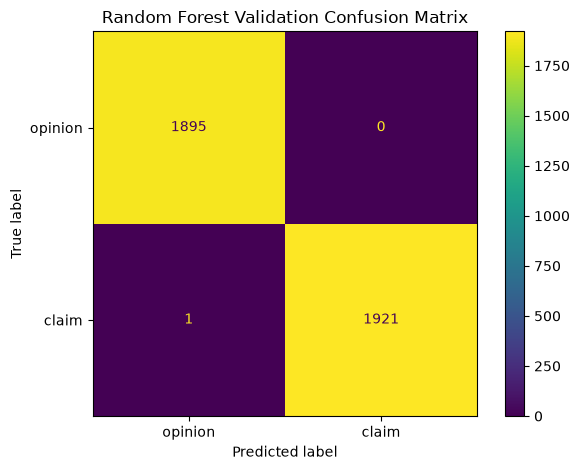

In [50]:

# Random Forest validation confusion matrix
rf_val_cm = confusion_matrix(
    y_val,
    rf_val_pred,
    labels=[0, 1]
)

rf_val_disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_val_cm,
    display_labels=["opinion", "claim"]
)

rf_val_disp.plot()

plt.title("Random Forest Validation Confusion Matrix")
plt.tight_layout()
plt.show()

### Validation Findings

The Random Forest performs exceptionally well on the validation set, correctly classifying **3,816 out of 3,817 videos**.

Only **one claim video** is misclassified as an opinion, while no opinion videos are incorrectly classified as claims.

This is consistent with the classification report, where both classes achieve an F1 score of approximately **0.9997**. The validation results therefore indicate that the model's strong cross validated performance is also maintained on unseen validation data.

### Validation Evaluation: XGBoost


In [51]:

# XGBoost validation predictions
xgb_val_pred = xgb_cv.best_estimator_.predict(
    X_val_final
)

print(
    classification_report(
        y_val,
        xgb_val_pred,
        target_names=["opinion", "claim"],
        digits=4
    )
)


              precision    recall  f1-score   support

     opinion     0.9984    1.0000    0.9992      1895
       claim     1.0000    0.9984    0.9992      1922

    accuracy                         0.9992      3817
   macro avg     0.9992    0.9992    0.9992      3817
weighted avg     0.9992    0.9992    0.9992      3817



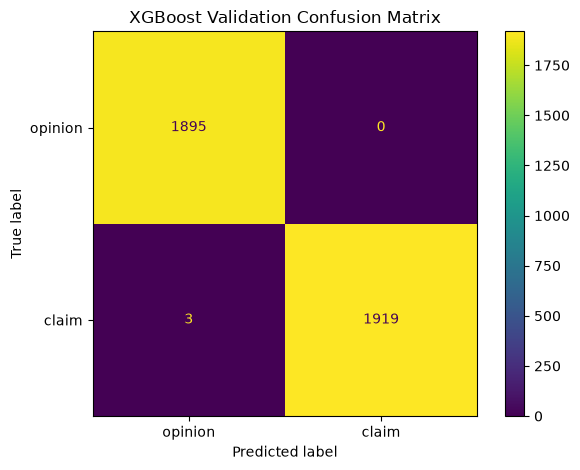

In [52]:

# XGBoost validation confusion matrix
xgb_val_cm = confusion_matrix(
    y_val,
    xgb_val_pred,
    labels=[0, 1]
)

xgb_val_disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_val_cm,
    display_labels=["opinion", "claim"]
)

xgb_val_disp.plot()

plt.title("XGBoost Validation Confusion Matrix")
plt.tight_layout()
plt.show()

### Validation Findings

The XGBoost model correctly classifies **3,814 out of 3,817 videos**, with only **three misclassified claims**.

No opinion videos are incorrectly classified as claims. The three errors are all false negatives, where claim videos are predicted as opinions.

This is consistent with the very high validation performance, although Random Forest makes fewer errors on the same validation set, with one misclassification compared with three for XGBoost.

### Final Model Selection

The validation results are used to select the model that will be evaluated once on the untouched test set

In [53]:

# Compare validation recall
rf_val_recall = recall_score(
    y_val,
    rf_val_pred
)

xgb_val_recall = recall_score(
    y_val,
    xgb_val_pred
)

if rf_val_recall >= xgb_val_recall:
    champion_model = rf_cv.best_estimator_
    champion_name = "Random Forest"
    champion_val_pred = rf_val_pred
else:
    champion_model = xgb_cv.best_estimator_
    champion_name = "XGBoost"
    champion_val_pred = xgb_val_pred

print(f"Selected model: {champion_name}")
print(f"Validation recall: {recall_score(y_val, champion_val_pred):.4f}")
print(f"Validation precision: {precision_score(y_val, champion_val_pred):.4f}")
print(f"Validation F1: {f1_score(y_val, champion_val_pred):.4f}")



Selected model: Random Forest
Validation recall: 0.9995
Validation precision: 1.0000
Validation F1: 0.9997



Random Forest achieves a slightly higher recall on the validation set than XGBoost, while both models demonstrate very strong performance.

Since identifying as many actual claims as possible is the primary objective, the model with the higher validation recall is selected for the final test evaluation.

The test set will remain untouched until this point to provide an unbiased estimate of the selected model's performance on unseen data.

## 8. Final Test Evaluation

The selected model is now evaluated on the held out test set.

The test set has not been used for model fitting, hyperparameter tuning, or model selection.

In [54]:

# Final predictions on the untouched test set
test_pred = champion_model.predict(
    X_test_final
)

# Calculate final metrics
test_accuracy = accuracy_score(
    y_test,
    test_pred
)

test_precision = precision_score(
    y_test,
    test_pred
)

test_recall = recall_score(
    y_test,
    test_pred
)

test_f1 = f1_score(
    y_test,
    test_pred
)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

Accuracy : 0.9995
Precision: 1.0000
Recall   : 0.9990
F1 Score : 0.9995



The selected Random Forest model was evaluated once on the untouched test set to measure its performance on completely unseen data.

The model achieved **99.95% accuracy**, with **100.00% precision**, **99.90% recall**, and an **F1 score of 99.95%**.

The close agreement between the cross validation, validation, and final test results indicates that the model's performance remains highly consistent across different evaluation stages.

The very high recall shows that the model identifies almost all positive class cases, while the perfect precision indicates that the positive predictions made by the model were correct in this test set.

These results provide strong evidence of predictive performance on this dataset. However, because the dataset is simulated and created for educational purposes, additional testing on real world data would be required before considering practical deployment.

### Final Classification Report


In [55]:

print(
    classification_report(
        y_test,
        test_pred,
        target_names=["opinion", "claim"],
        digits=4
    )
)

              precision    recall  f1-score   support

     opinion     0.9989    1.0000    0.9995      1895
       claim     1.0000    0.9990    0.9995      1922

    accuracy                         0.9995      3817
   macro avg     0.9995    0.9995    0.9995      3817
weighted avg     0.9995    0.9995    0.9995      3817



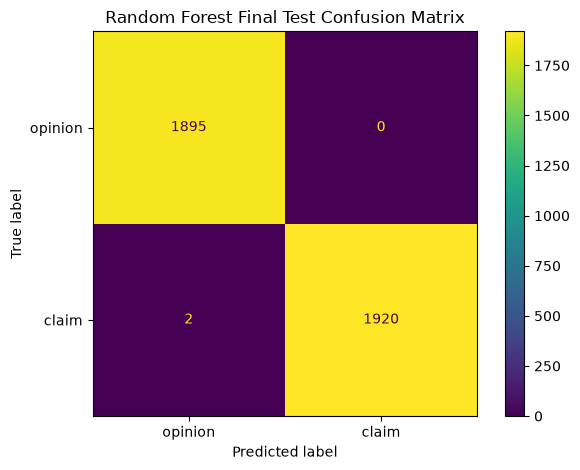

In [56]:

# Final confusion matrix
test_cm = confusion_matrix(
    y_test,
    test_pred,
    labels=[0, 1]
)

test_disp = ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=["opinion", "claim"]
)

test_disp.plot()

plt.title(f"{champion_name} Final Test Confusion Matrix")
plt.tight_layout()
plt.show()

### Final Test Findings

The final test confusion matrix shows that the selected Random Forest correctly classified **3,815 out of 3,817 videos**.

It correctly identified all **1,895 opinion videos**, with no opinion videos incorrectly classified as claims.

For the claim class, **1,920 videos were correctly identified**, while only **2 claim videos were misclassified as opinions**.

This confirms the final test metrics, with very high precision and recall and only two classification errors on the unseen test set.

## 9. Model Interpretability

Understanding which features contribute most strongly to the model can help explain the predictions and connect the machine learning results back to the exploratory analysis.

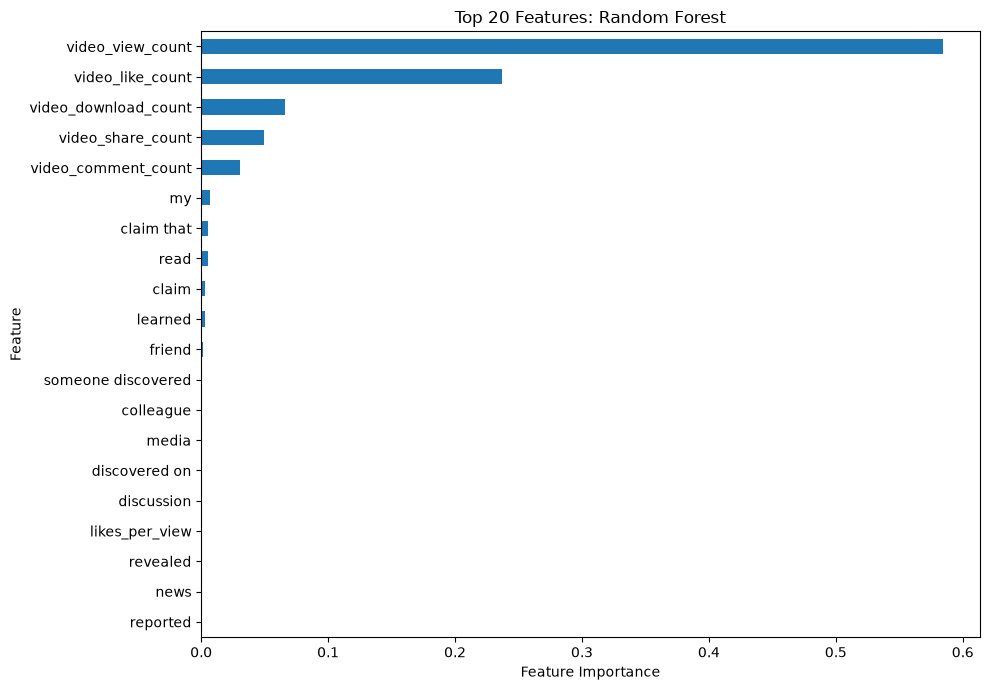

In [57]:

# Extract feature importances from the champion model
if hasattr(champion_model, "feature_importances_"):
    feature_importances = pd.Series(
        champion_model.feature_importances_,
        index=X_train_final.columns
    ).sort_values(
        ascending=False
    )

    top_features = feature_importances.head(20)

    top_features


# Visualize the top 20 feature importances
plt.figure(figsize=(10, 7))

top_features.sort_values().plot.barh()

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(f"Top 20 Features: {champion_name}")
plt.tight_layout()
plt.show()

## 10. Save Trained Models

In [58]:
import pickle
import os

# Create models folder if it does not exist
os.makedirs("models", exist_ok=True)

# Save Random Forest
with open("models/random_forest_model.pkl", "wb") as file:
    pickle.dump(rf_cv.best_estimator_, file)

# Save XGBoost
with open("models/xgboost_model.pkl", "wb") as file:
    pickle.dump(xgb_cv.best_estimator_, file)

# Save CountVectorizer
with open("models/count_vectorizer.pkl", "wb") as file:
    pickle.dump(count_vec, file)

print("Models and CountVectorizer saved successfully.")

Models and CountVectorizer saved successfully.


### Feature Importance Findings

The Random Forest feature importance results show that video engagement variables have the highest model based importance.

`video_view_count` has the highest importance, followed by `video_like_count`, `video_download_count`, `video_share_count`, and `video_comment_count`.

Text based features have substantially lower individual importance than the main engagement variables.

These results describe how the Random Forest uses the available features and should not be interpreted as evidence of causal relationships.

## Key Findings

The analysis identified several important patterns in the data:

1. Claim and opinion videos differ in their engagement levels, with claim videos generally receiving higher views and other forms of engagement.

2. Transcription length also differs between the two classes. Claim videos have an average transcription length of approximately 95 characters, compared with approximately 83 characters for opinion videos.

3. Both Random Forest and XGBoost achieved very high validation performance. Random Forest achieved a cross validated accuracy of 0.9993, recall of 0.9986, and F1 score of 0.9993. XGBoost achieved an accuracy of 0.9984, recall of 0.9972, and F1 score of 0.9984.

4. Random Forest was selected as the final model based on its validation recall.

5. On the final test set, the Random Forest correctly classified 1,895 opinion videos and 1,920 claim videos, with only 2 misclassified videos out of 3,817 observations.

6. Feature importance analysis shows that engagement variables, especially video view count and video like count, contribute most strongly to the Random Forest predictions. Text based features have substantially lower individual importance.

## Business Interpretation

The results suggest that the classification model can effectively distinguish between claims and opinions within the available dataset.

For a moderation workflow, the model could be used to help prioritize reported videos for further review. The final Random Forest model correctly identified 1,920 of the 1,922 claim videos in the test set, while none of the 1,895 opinion videos were classified as claims.

The feature importance results show that video engagement variables, particularly views and likes, provide most of the predictive information used by the model. This means that the model is relying more heavily on engagement patterns than on the individual text features extracted from video transcriptions.

These results describe patterns learned by the model and should not be interpreted as evidence that higher engagement causes a video to be a claim.

### Limitations

This case study uses a simulated dataset created for educational purposes.

The observed relationships and model performance should therefore not be interpreted as evidence about real TikTok systems or real world moderation performance.

In addition, engagement variables may reflect information that becomes available after a video has already accumulated views and interactions. In a real deployment, the availability of each feature at prediction time would need to be verified to prevent temporal leakage.

The model should also be validated on additional real world data before being considered for production use.

## Conclusion

The analysis successfully developed a machine learning approach for classifying TikTok videos as claims or opinions.

Random Forest and XGBoost both achieved very high performance during validation, with Random Forest showing the highest recall and being selected as the final model.

The final test evaluation showed that Random Forest correctly classified 3,815 out of 3,817 videos, with an accuracy of 0.9995, precision of 1.0000, recall of 0.9990, and F1 score of 0.9995.

The feature importance analysis showed that video engagement variables were the dominant predictors, particularly video views and likes. This finding is consistent with the patterns observed during exploratory analysis.

Although the model performed extremely well on the available test set, the dataset was created for educational purposes. Therefore, the results should be validated on additional real world data before considering deployment. Future analysis could also incorporate information such as user report history and author level reporting patterns to provide additional predictive signals.